In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
employment = pd.read_csv("/kaggle/input/datasets/lucalullo/global-employment-unemployment-rates-1991-2025/occupazione.csv")
unemployment = pd.read_csv('/kaggle/input/datasets/lucalullo/global-employment-unemployment-rates-1991-2025/disoccupazione.csv')

dfs = {'Employment' : employment,
      'Unemployment' : unemployment}

In [6]:
for name, df in dfs.items():
    print(f'--- {name} Info ---')
    print(df.info())
    print('--' * 30)

--- Employment Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57519 entries, 0 to 57518
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iso_code   57519 non-null  object 
 1   country    57519 non-null  object 
 2   sex        57519 non-null  object 
 3   age        57519 non-null  object 
 4   year       57519 non-null  int64  
 5   obs_value  57519 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.6+ MB
None
------------------------------------------------------------
--- Unemployment Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57519 entries, 0 to 57518
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iso_code   57519 non-null  object 
 1   country    57519 non-null  object 
 2   sex        57519 non-null  object 
 3   age        57519 non-null  object 
 4   year       57519 non-null  int64  
 5   o

In [8]:
for name, df in dfs.items():
    # Check unique categories for both datasets
    print("--- Unique Categories in Employment Data ---")
    print("Sex Categories:", df['sex'].unique())
    print("Age Groups:", df['age'].unique())
    
    print("\n--- Unique Categories in Unemployment Data ---")
    print("Sex Categories:", df['sex'].unique())
    print("Age Groups:", df['age'].unique())
    
    # Quick check on the year range
    print(f"\nYear Range: {df['year'].min()} to {df['year'].max()}")

--- Unique Categories in Employment Data ---
Sex Categories: ['Total' 'Male' 'Female']
Age Groups: ['15+' '15-24' '25+']

--- Unique Categories in Unemployment Data ---
Sex Categories: ['Total' 'Male' 'Female']
Age Groups: ['15+' '15-24' '25+']

Year Range: 1991 to 2025
--- Unique Categories in Employment Data ---
Sex Categories: ['Total' 'Male' 'Female']
Age Groups: ['15+' '15-24' '25+']

--- Unique Categories in Unemployment Data ---
Sex Categories: ['Total' 'Male' 'Female']
Age Groups: ['15+' '15-24' '25+']

Year Range: 1991 to 2025


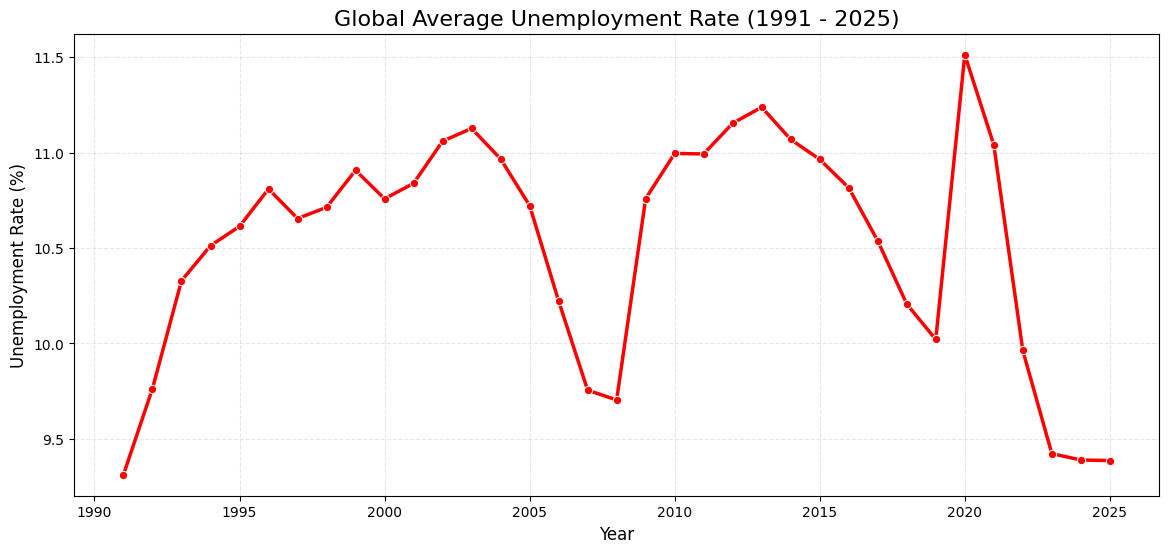

In [11]:
# Global Unemployment trend
global_unemp = unemployment[(unemployment['sex'] == 'Total') & (unemployment['age'] == '15+')]
yearly_trend = unemployment.groupby('year')['obs_value'].mean().reset_index()

# 3. Create the Time-Series Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_trend, x='year', y='obs_value', marker='o', color='red', linewidth=2.5)

plt.title('Global Average Unemployment Rate (1991 - 2025)', fontsize=16)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.show()

In [18]:
# Country-Level Performance (The Best & Worst)
# 1. Filter for the most recent year (2025)
latest_data = unemployment[(unemployment['year'] == 2025) & (unemployment['sex'] == 'Total') & (unemployment['age'] == '15+')]

# 2. Sort to find Extremes
top_10_unemp = latest_data.sort_values(by='obs_value', ascending=False).head(10)
bottom_10_unemp = latest_data.sort_values(by='obs_value', ascending=True).head(10)

print("--- Top 10 Countries with Highest Predicted Unemployment (2025) ---")
print(top_10_unemp[['country', 'obs_value']])

--- Top 10 Countries with Highest Predicted Unemployment (2025) ---
                                country  obs_value
48735                          Eswatini     34.202
56574                      South Africa     32.391
13545                          Djibouti     26.015
7875                           Botswana     24.477
17955                             Gabon     20.154
10710                             Congo     19.876
36837                           Namibia     19.291
46233                           Somalia     18.948
29277                             Libya     18.758
54684  Saint Vincent and the Grenadines     18.003


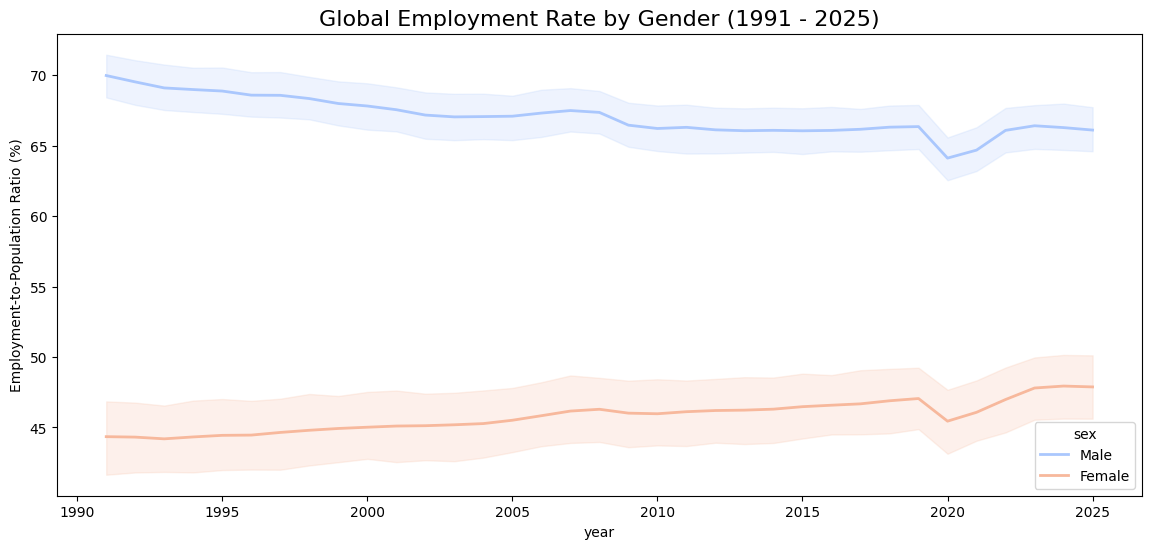

In [19]:
# Gender Disparity (Male vs. Female)
# 1. Filter for Male and Female (Age 15+)
gender_emp = employment[(employment['sex'].isin(['Male', 'Female'])) & (employment['age'] == '15+')]

# 2. Group and Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=gender_emp, x='year', y='obs_value', hue='sex', palette='coolwarm', linewidth=2)

plt.title('Global Employment Rate by Gender (1991 - 2025)', fontsize=16)
plt.ylabel('Employment-to-Population Ratio (%)')
plt.show()

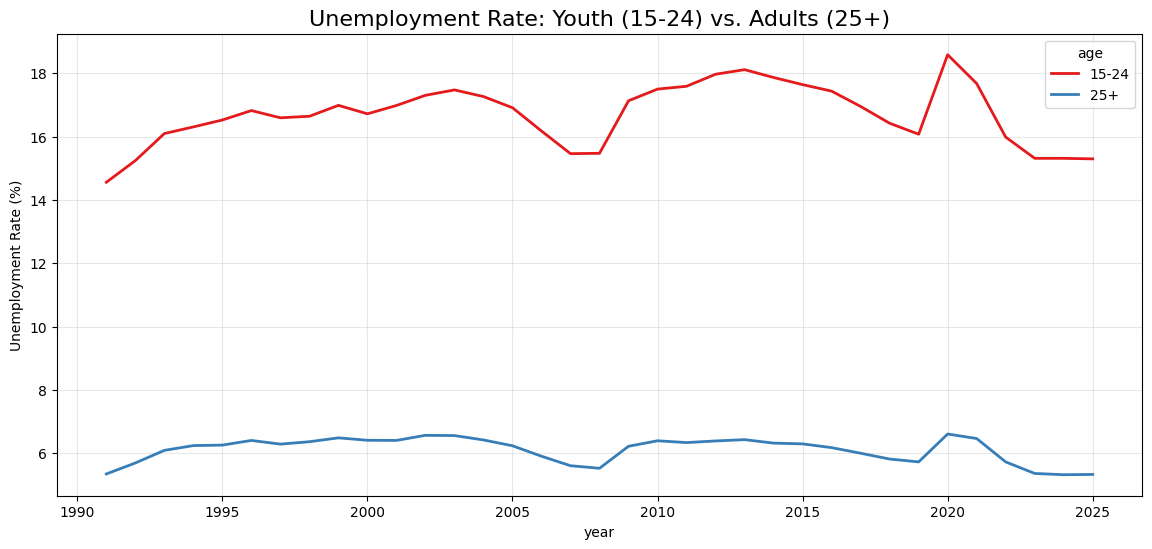

In [20]:
# The Youth vs. Adult Gap (15-24 vs. 25+)
# 1. Filter for the two specific age groups (Total sex)
age_comparison = unemployment[(unemployment['sex'] == 'Total') & (unemployment['age'].isin(['15-24', '25+']))]

# 2. Group by year and age
age_trends = age_comparison.groupby(['year', 'age'])['obs_value'].mean().reset_index()

# 3. Plot the comparison
plt.figure(figsize=(14, 6))
sns.lineplot(data=age_trends, x='year', y='obs_value', hue='age', palette='Set1', linewidth=2)

plt.title('Unemployment Rate: Youth (15-24) vs. Adults (25+)', fontsize=16)
plt.ylabel('Unemployment Rate (%)')
plt.grid(True, alpha=0.3)
plt.show()

📊 Key Insights
-   **The 2020 Pivot:** The dataset identifies 2020 as the most volatile year in modern labor history, with global unemployment spiking to an all-time high of **11.5%**, nearly 1.5% higher than the 2008 financial crisis.

-   **Generational Inequality:** There is a persistent "Youth Gap." The unemployment rate for the **15--24 demographic** is consistently **3x higher** than the 25+ age group, highlighting that younger workers are the most vulnerable to economic shocks.

-   **The Gender Participation Gap:** While global male employment has seen a slight downward trend (70% to 66%), female employment is slowly rising (44% to 48%). However, a significant **18% participation gap** remains as of the 2025 projections.

-   **Regional Distress:** Labor market struggles are heavily localized. Southern Africa remains the most challenged region, with countries like **Eswatini** and **South Africa** predicted to face unemployment rates exceeding **30%** in 2025.